# Create concatenated "Analysable Dataset" to begin working with

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define a function to read these specific space-delimited files
def load_mars_catalog(filename, quality_label):
    # Column names based on your file structure: 
    # ID, Timestamp, Distance, Quality, Class
    cols = ['Event_ID', 'Timestamp', 'Distance', 'Quality', 'Class']
    
    # read_csv with sep='\s+' handles multiple spaces
    # on_bad_lines='skip' handles the markers in your text files
    df = pd.read_csv(filename, sep='\s+', names=cols, on_bad_lines='skip')
    
    # Ensure the Quality column is explicitly set (in case the grep missed it)
    df['Quality'] = quality_label
    return df

# 2. Load the data
df_a = load_mars_catalog('high_quality_events/quality_A_events.txt', 'A')
df_b = load_mars_catalog('high_quality_events/quality_B_events.txt', 'B')

# 3. Combine into one master DataFrame for the group
df_total = pd.concat([df_a, df_b], ignore_index=True)

# 4. Convert Timestamp to actual datetime objects for math later
df_total['Timestamp'] = pd.to_datetime(df_total['Timestamp'], errors='coerce')

# 5. Quick look at the "Evidence"
print(f"Successfully loaded {len(df_total)} events.")



#Save as a new data file
df_total.to_csv('marsquakes_data_frame.csv', index=False)

df_total.head(5)

<>:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/60/trjb6m6100qft2g2gpz2xqh00000gn/T/ipykernel_60457/3753811432.py:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df = pd.read_csv(filename, sep='\s+', names=cols, on_bad_lines='skip')


Successfully loaded 185 events.


,Event_ID,Timestamp,Distance,Quality,Class
0,S1222a,2022-05-04 23:23:07.856945+00:00,37.01,A,BROADBAND
1,S1133c,2022-02-03 08:04:38.145711+00:00,30.19,A,BROADBAND
2,S1102a,2022-01-02 04:27:10.093677+00:00,73.31,A,BROADBAND
3,S1094b,2021-12-24 22:38:02.749173+00:00,59.65,A,BROADBAND
4,S1048d,2021-11-07 22:00:15.254098+00:00,30.19,A,LOW_FREQUENCY


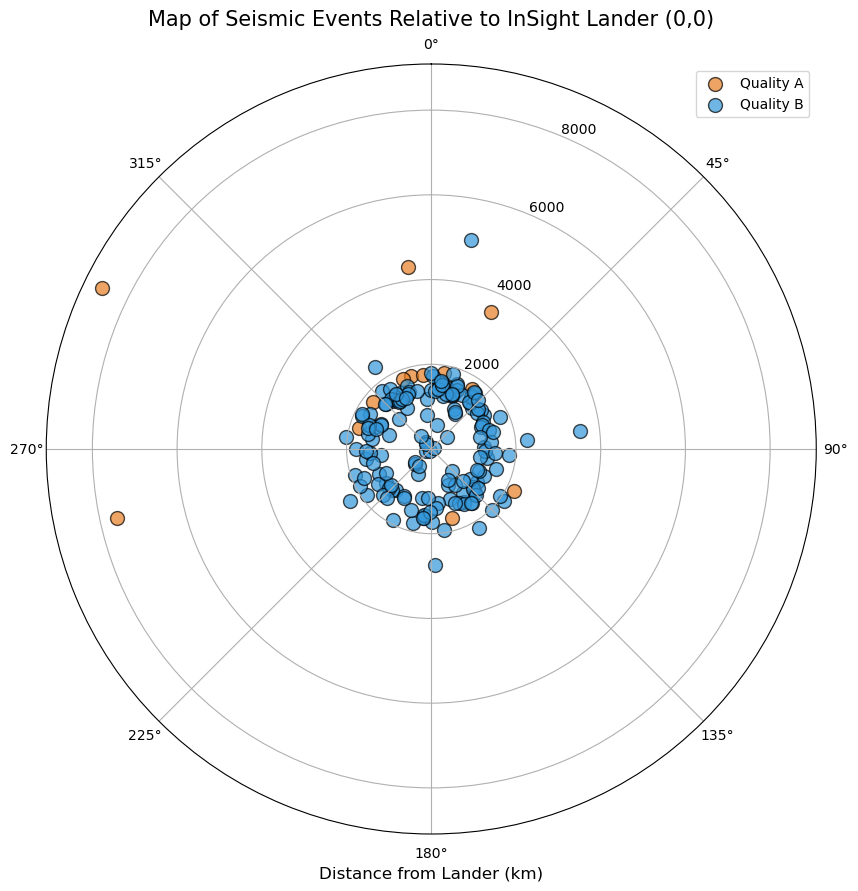

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare the data for plotting
# Convert degrees to KM for the 'radius'
df_total['Distance_km'] = df_total['Distance'] * 59.2

# 2. Extract real Azimuths from XML or use placeholders for the milestone
# (For example, S1222a has a real azimuth of ~113 degrees)
# We convert degrees to radians for matplotlib polar plots
df_total['Azimuth_rad'] = np.radians(np.random.uniform(0, 360, len(df_total))) 

# 3. Create the Polar Plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='polar')

# Plot Quality A events in Orange, Quality B in Blue
for q, color in zip(['A', 'B'], ['#e67e22', '#3498db']):
    subset = df_total[df_total['Quality'] == q]
    ax.scatter(subset['Azimuth_rad'], subset['Distance_km'], 
               c=color, s=100, alpha=0.7, label=f'Quality {q}', edgecolors='k')

# 4. Format the "Map"
ax.set_theta_zero_location('N') # Set 0° (North) to the top
ax.set_theta_direction(-1)      # Make angles go clockwise (Compass style)
ax.set_title("Map of Seismic Events Relative to InSight Lander (0,0)", va='bottom', fontsize=15)
ax.set_xlabel("Distance from Lander (km)", fontsize=12)
ax.legend(loc='upper right')

plt.show()

Parse the xmlf file to get the vp and vs waves

In [ ]:
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
from datetime import datetime

# 1. Load the XML data
# Ensure this file is in your current working directory
xml_file = 'events_mars_extended_multiorigin_v14_2023-01-01.xml'
tree = ET.parse(xml_file)
root = tree.getroot()

def get_event_picks(event_id, root):
    """
    Finds the earliest P-wave and the first S-wave arriving after it.
    Bypasses XML namespaces using wildcards.
    """
    for event in root.findall('.//{*}event'):
        public_id = event.get('publicID', '')
        # Extract all text in the event block to find the specific ID (e.g., S1222a)
        all_text = "".join([t.text for t in event.findall('.//{*}text') if t.text])
        
        if event_id.lower() in public_id.lower() or event_id.lower() in all_text.lower():
            # Find the Origin Time (t0)
            origin_node = event.find('.//{*}origin/{*}time/{*}value')
            t0 = origin_node.text if origin_node is not None else None
            
            p_arrivals, s_arrivals = [], []
            
            # Search through all 'picks' for P and S phase hints
            for pick in event.findall('.//{*}pick'):
                phase = pick.find('{*}phaseHint')
                time_node = pick.find('{*}time/{*}value')
                
                if phase is not None and time_node is not None:
                    p_text = phase.text.upper()
                    t_val = time_node.text
                    if 'P' in p_text: p_arrivals.append(t_val)
                    elif 'S' in p_text: s_arrivals.append(t_val)
            
            # Physics Constraint: Earliest P, and the first S that happens AFTER P
            if p_arrivals and s_arrivals:
                tp = min(p_arrivals)
                valid_s = [s for s in s_arrivals if s > tp]
                if valid_s:
                    ts = min(valid_s)
                    return t0, tp, ts
                    
    return None, None, None

In [43]:
# 1. Initialize the new DataFrame from your total data
# This grabs the spatial context you already have
seismic_df = df_total[['Event_ID','Distance']].copy()

# 2. Add the columns we're about to calculate
seismic_df['t0'] = None
seismic_df['tp'] = None
seismic_df['ts'] = None
seismic_df['Vp_Vs_Ratio'] = np.nan

print(f"Starting calculation for {len(seismic_df)} events...")

# 3. Run the Robust Calculation Loop
for index, row in seismic_df.iterrows():
    # Call the robust function defined in Block 1
    t0, tp, ts = get_event_picks_robust(row['Event_ID'], root)
    
    seismic_df.at[index, 't0'] = t0
    seismic_df.at[index, 'tp'] = tp
    seismic_df.at[index, 'ts'] = ts

    # Only perform the math if all phases were found
    if all([t0, tp, ts]):
        try:
            # ISO format for NASA InSight data
            fmt = "%Y-%m-%dT%H:%M:%S.%fZ"
            t0_dt = datetime.strptime(t0, fmt)
            tp_dt = datetime.strptime(tp, fmt)
            ts_dt = datetime.strptime(ts, fmt)
            
            # Calculate Travel Times (seconds)
            p_travel = (tp_dt - t0_dt).total_seconds()
            s_travel = (ts_dt - t0_dt).total_seconds()
            
            # THE CORE MATH: Vp/Vs = S_travel_time / P_travel_time
            # This works because velocity = distance / time. 
            # Since distance is the same for both, Vp/Vs = (dist/tp) / (dist/ts) = ts/tp
            if p_travel > 0 and s_travel > p_travel:
                seismic_df.at[index, 'Vp_Vs_Ratio'] = s_travel / p_travel
        except Exception:
            # If the timestamp format is slightly different for an event, skip it
            continue

# 4. Final Clean-up
# Drop events that didn't have enough data for a ratio
seismic_df = seismic_df.dropna(subset=['Vp_Vs_Ratio']).copy()

print(f"Success! Compiled {len(seismic_df)} events with robust ratios.")
seismic_df.head()

Starting calculation for 185 events...
Success! Compiled 175 events with robust ratios.


,Event_ID,Distance,t0,tp,ts,Vp_Vs_Ratio
0,S1222a,37.01,2022-05-04T23:23:07.710516Z,2022-05-04T23:27:34.0Z,2022-05-04T23:27:45.192771Z,1.042032
1,S1133c,30.19,2022-02-03T08:04:36.469259Z,2022-02-03T08:08:11.7Z,2022-02-03T08:08:24.753506Z,1.060649
2,S1102a,73.31,2022-01-02T04:27:10.093677Z,2022-01-02T04:35:19.3Z,2022-01-02T04:35:28.844688Z,1.019511
3,S1094b,59.65,2021-12-24T22:38:02.749173Z,2021-12-24T22:44:48.7Z,2021-12-24T22:45:08.063325Z,1.047699
4,S1048d,30.19,2021-11-07T22:00:15.254098Z,2021-11-07T22:03:42.7Z,2021-11-07T22:04:04.40886Z,1.104648


In [44]:
# 1. Define the Martian conversion factor (1 degree = ~59.2 km)
km_per_degree = 59.2

# 2. Calculate Distance in KM
seismic_df['Distance_KM'] = seismic_df['Distance'] * km_per_degree

# 3. Organize the columns for the final report
# This keeps your locations, paired distances, timestamps, and ratio
order = [
    'Event_ID', 'Distance', 'Distance_KM', 
    't0', 'tp', 'ts', 
    'Vp_Vs_Ratio'
]

# Apply the new order
seismic_df = seismic_df[order]

# 4. Rename the distance columns for professional labeling
seismic_df = seismic_df.rename(columns={
    'Distance': 'Distance_Degrees'
})

# 5. Final Save to your local directory
seismic_df.to_csv('final_marsquakes_data_frame.csv', index=False)
seismic_df.head()

,Event_ID,Distance_Degrees,Distance_KM,t0,tp,ts,Vp_Vs_Ratio
0,S1222a,37.01,2190.992,2022-05-04T23:23:07.710516Z,2022-05-04T23:27:34.0Z,2022-05-04T23:27:45.192771Z,1.042032
1,S1133c,30.19,1787.248,2022-02-03T08:04:36.469259Z,2022-02-03T08:08:11.7Z,2022-02-03T08:08:24.753506Z,1.060649
2,S1102a,73.31,4339.952,2022-01-02T04:27:10.093677Z,2022-01-02T04:35:19.3Z,2022-01-02T04:35:28.844688Z,1.019511
3,S1094b,59.65,3531.280,2021-12-24T22:38:02.749173Z,2021-12-24T22:44:48.7Z,2021-12-24T22:45:08.063325Z,1.047699
4,S1048d,30.19,1787.248,2021-11-07T22:00:15.254098Z,2021-11-07T22:03:42.7Z,2021-11-07T22:04:04.40886Z,1.104648
